In [1]:
from resources.imports import *

from resources.lattices import calcK_mohr, calcC_sims, plot_IsotropyVariation, calc_IsoEffProperties, calc_ZenerRatio

In [15]:
LAT = "FCC"
dis = 'disNodes'      # None, dn, ds

# Truss Axial Plasticity Method

In [16]:
l = 0.01
nnx = 10

Ks_mohr = calcK_mohr(LAT, l, nnx, "lattice", dis=dis, count=20, plot=False)
Kunit_mohr = calcK_mohr(LAT, l, nnx, "unit", plot=False)

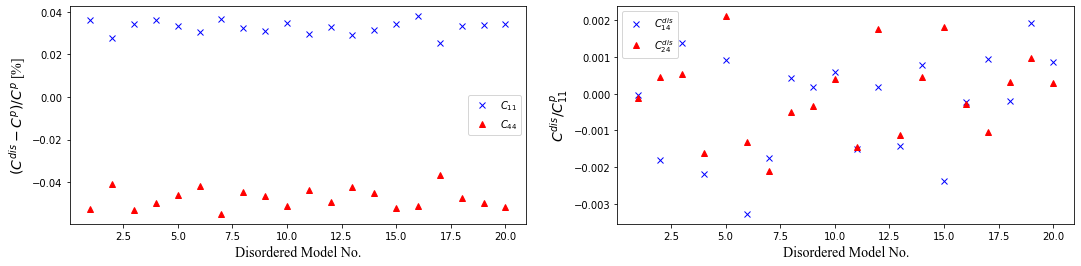

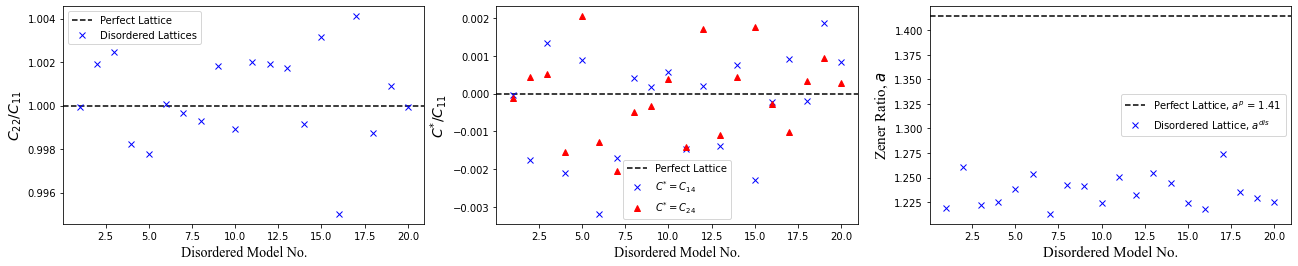

In [18]:
plot_IsotropyVariation(Ks_mohr, stiff=True, paper=True)

In [6]:
E_eff, v_eff, iso = calc_IsoEffProperties(Kunit_mohr[0])
E_eff, v_eff, iso

(7687500000.0, 0.25, True)

In [11]:
v_eff = 1/3
K_iso_pStress = (1/(1-v_eff**2))*np.array([[1, v_eff, 0],
                                           [v_eff, 1, 0],
                                           [0, 0, (1-v_eff)/2]])
K_iso_pStrain = (1/((1-2*v_eff)*(1+v_eff)))*np.array([[1-v_eff, v_eff, 0],
                                                      [v_eff, 1-v_eff, 0],
                                                      [0, 0, (1-2*v_eff)/2]])

np.around(K_iso_pStress/min(K_iso_pStress[0][:2]),2), np.around(K_iso_pStrain/min(K_iso_pStrain[0][:2]))

(array([[3., 1., 0.],
        [1., 3., 0.],
        [0., 0., 1.]]),
 array([[2., 1., 0.],
        [1., 2., 0.],
        [0., 0., 1.]]))

# Beam-Based Homogenization Method

In [20]:
nnx = 20
if LAT.lower() == "tri":
    nnx = 30

C = calcC_sims(LAT, nnx, dis=dis, count=5, pDir=r"Z:\p1\sims\Ti\stiffMatrix\Cmatrix-periodic\\")

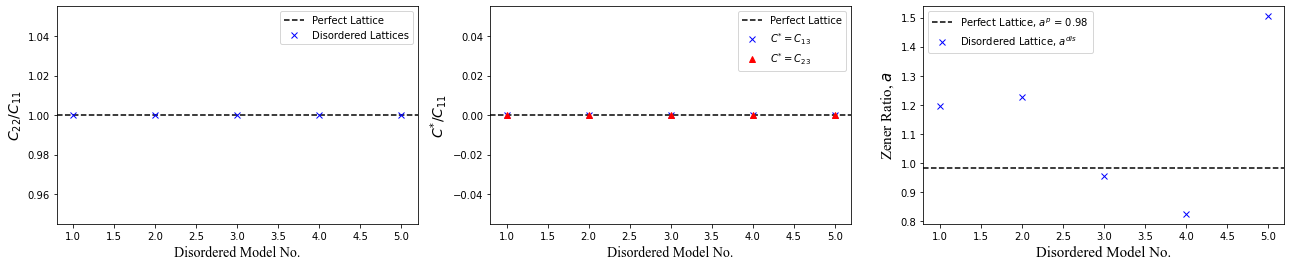

In [22]:
plot_IsotropyVariation(C, paper=True)